# 1. Importación de Librerías y Definición de la Arquitectura


In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split


torch.manual_seed(42)

# 2. Extracción, Transformación y Partición (ETL)
La transformación fundamental aquí es ToTensor(). Esta operación toma las imágenes originales (arreglos de píxeles con valores de 0 a 255) y las convierte en tensores de punto flotante normalizados en el rango $[0.0, 1.0]$.


Para la arquitectura del entrenamiento, dividir los datos es crucial. Usaremos random_split para aislar 10,000 muestras de validación. Esto evita que el modelo memorice los datos y nos permite evaluar su capacidad de generalización en cada época, antes de la prueba final (test).

In [24]:
# 1. Transformación
transform = transforms.ToTensor()

# 2. Carga de Datasets (Extracción)
dataset_completo = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
dataset_test = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# 3. Partición (Train / Val)
train_size = 50000
val_size = 10000
dataset_train, dataset_val = random_split(dataset_completo, [train_size, val_size])

print(f"Entrenamiento: {len(dataset_train)}")
print(f"Validación: {len(dataset_val)}")
print(f"Prueba: {len(dataset_test)}")

Entrenamiento: 50000
Validación: 10000
Prueba: 10000


 # 3. Perceptron Multicapa
 
 Las imágenes de MNIST tienen dimensiones $28 \times 28$. Como las capas densas (nn.Linear) requieren vectores unidimensionales, la primera operación lógica en el método forward debe ser "aplanar" (flatten) la imagen en un vector de características de tamaño $784$.

In [25]:
class RedClasificacion(nn.Module):
    def __init__(self, tamano_entrada=784, neuronas_ocultas=[128, 64], num_clases=10):
        super(RedClasificacion, self).__init__()
        
        # Construcción dinámica de la arquitectura usando capas Lineales y ReLU
        capas = []
        entrada_actual = tamano_entrada
        
        for neuronas in neuronas_ocultas:
            capas.append(nn.Linear(entrada_actual, neuronas))
            capas.append(nn.ReLU())
            entrada_actual = neuronas
            
        # Capa de salida (Sin ReLU al final, la función de pérdida manejará las probabilidades)
        capas.append(nn.Linear(entrada_actual, num_clases))
        
        self.red = nn.Sequential(*capas)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.red(x)

# 4.  Lógica del Bucle de Entrenamiento
En lugar de reescribir el bucle tres veces, crearemos una función que orqueste la arquitectura del entrenamiento.El flujo lógico dentro de cada mini-batch es estricto:Forward Pass: Propagar los datos por la red para obtener predicciones.Loss: Calcular el error usando CrossEntropyLoss (ideal para clasificación multiclase, ya que aplica internamente Softmax y calcula el logaritmo de la pérdida).Zero Grad: Limpiar los gradientes de la iteración anterior.Backward Pass: Calcular los nuevos gradientes mediante backpropagation ($\frac{\partial L}{\partial W}$).Optimizer Step: Actualizar los pesos de la red.

In [26]:
def entrenar_modelo(modelo, train_loader, val_loader, optimizador, criterio, epocas):
    historial = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    
    for epoca in range(epocas):
        modelo.train() # Modo entrenamiento
        loss_acumulada = 0.0
        
        # Iteración sobre mini-batches
        for inputs, labels in train_loader:
            optimizador.zero_grad()
            
            salidas = modelo(inputs)
            loss = criterio(salidas, labels)
            
            loss.backward()
            optimizador.step()
            
            loss_acumulada += loss.item() * inputs.size(0)
            
        train_loss = loss_acumulada / len(train_loader.dataset)
        historial['train_loss'].append(train_loss)
        
        # Evaluación en Validación
        modelo.eval() # Modo evaluación (apaga Dropout/BatchNorm si los hubiera)
        val_loss = 0.0
        correctos = 0
        
        with torch.no_grad(): # Desactivamos el cálculo de gradientes por eficiencia
            for inputs, labels in val_loader:
                salidas = modelo(inputs)
                loss = criterio(salidas, labels)
                val_loss += loss.item() * inputs.size(0)
                
                # La predicción es el índice con el valor máximo
                _, predicciones = torch.max(salidas, 1)
                correctos += (predicciones == labels).sum().item()
                
        val_loss = val_loss / len(val_loader.dataset)
        val_acc = correctos / len(val_loader.dataset)
        
        historial['val_loss'].append(val_loss)
        historial['val_acc'].append(val_acc)
        
        print(f"Época {epoca+1}/{epocas} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
        
    return historial

# 5. Entrenamiento de 3 Arquitecturas Distintas

Vamos a variar el número de capas/neuronas, el optimizador y el tamaño de los batches.

- Modelo 1: Red simple (1 capa oculta), Batch grande, Optimizador SGD básico.

- Modelo 2: Red más profunda (2 capas ocultas), Batch estándar, Optimizador Adam (convergencia más rápida adaptando el learning rate por parámetro).

- Modelo 3: Red ancha (1 capa oculta grande), Batch pequeño, SGD con Momentum.

La función de pérdida será estandarizada: nn.CrossEntropyLoss().

In [27]:
criterio = nn.CrossEntropyLoss()

print("--- EXPERIMENTO 1: Red Simple, SGD, Batch 256 ---")
loader_train_1 = DataLoader(dataset_train, batch_size=256, shuffle=True)
loader_val_1 = DataLoader(dataset_val, batch_size=256, shuffle=False)
modelo_1 = RedClasificacion(neuronas_ocultas=[64])
opt_1 = optim.SGD(modelo_1.parameters(), lr=0.1)
hist_1 = entrenar_modelo(modelo_1, loader_train_1, loader_val_1, opt_1, criterio, epocas=5)

print("\n--- EXPERIMENTO 2: Red Profunda, Adam, Batch 64 ---")
loader_train_2 = DataLoader(dataset_train, batch_size=64, shuffle=True)
loader_val_2 = DataLoader(dataset_val, batch_size=64, shuffle=False)
modelo_2 = RedClasificacion(neuronas_ocultas=[128, 64])
opt_2 = optim.Adam(modelo_2.parameters(), lr=0.001)
hist_2 = entrenar_modelo(modelo_2, loader_train_2, loader_val_2, opt_2, criterio, epocas=5)

print("\n--- EXPERIMENTO 3: Red Ancha, SGD+Momentum, Batch 32 ---")
loader_train_3 = DataLoader(dataset_train, batch_size=32, shuffle=True)
loader_val_3 = DataLoader(dataset_val, batch_size=32, shuffle=False)
modelo_3 = RedClasificacion(neuronas_ocultas=[256])
opt_3 = optim.SGD(modelo_3.parameters(), lr=0.01, momentum=0.9)
hist_3 = entrenar_modelo(modelo_3, loader_train_3, loader_val_3, opt_3, criterio, epocas=5)

--- EXPERIMENTO 1: Red Simple, SGD, Batch 256 ---
Época 1/5 | Train Loss: 0.8806 | Val Loss: 0.4484 | Val Acc: 0.8749
Época 2/5 | Train Loss: 0.3750 | Val Loss: 0.3638 | Val Acc: 0.8975
Época 3/5 | Train Loss: 0.3240 | Val Loss: 0.3278 | Val Acc: 0.9042
Época 4/5 | Train Loss: 0.2966 | Val Loss: 0.3030 | Val Acc: 0.9119
Época 5/5 | Train Loss: 0.2770 | Val Loss: 0.2902 | Val Acc: 0.9164

--- EXPERIMENTO 2: Red Profunda, Adam, Batch 64 ---
Época 1/5 | Train Loss: 0.3740 | Val Loss: 0.2097 | Val Acc: 0.9386
Época 2/5 | Train Loss: 0.1573 | Val Loss: 0.1496 | Val Acc: 0.9565
Época 3/5 | Train Loss: 0.1064 | Val Loss: 0.1256 | Val Acc: 0.9627
Época 4/5 | Train Loss: 0.0789 | Val Loss: 0.1077 | Val Acc: 0.9675
Época 5/5 | Train Loss: 0.0619 | Val Loss: 0.1017 | Val Acc: 0.9693

--- EXPERIMENTO 3: Red Ancha, SGD+Momentum, Batch 32 ---
Época 1/5 | Train Loss: 0.3799 | Val Loss: 0.2167 | Val Acc: 0.9378
Época 2/5 | Train Loss: 0.1677 | Val Loss: 0.1539 | Val Acc: 0.9533
Época 3/5 | Train Loss:

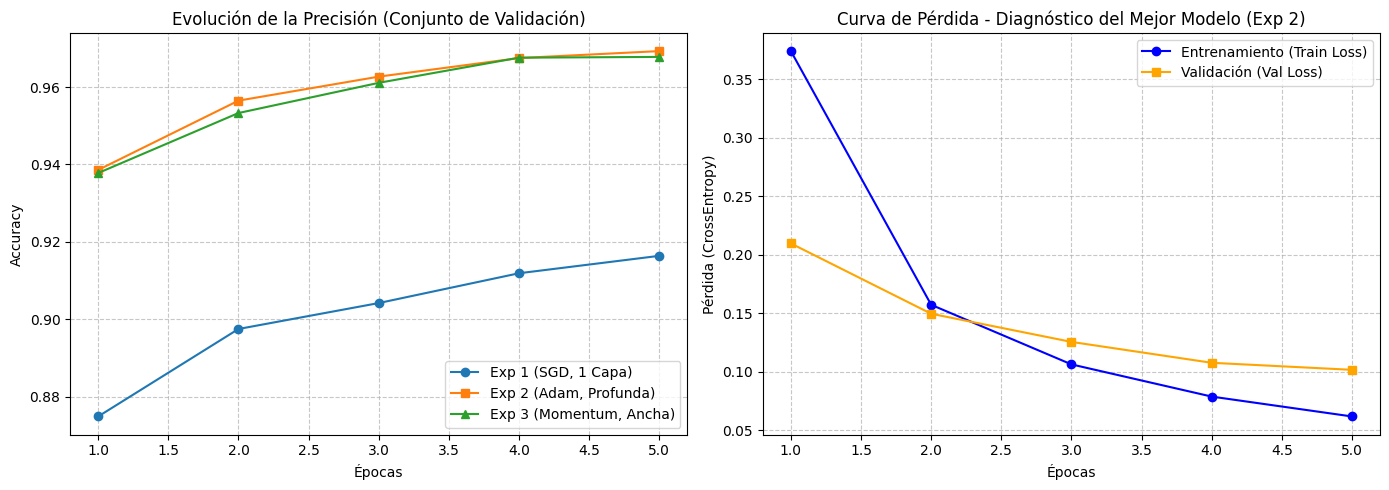

In [28]:
import matplotlib.pyplot as plt

# Configuramos el lienzo con dos subgráficos (1 fila, 2 columnas)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epocas_rango = range(1, 6) # Tuvimos 5 épocas en los experimentos

# --- Lógica Visual 1: Comparativa de Accuracy entre Arquitecturas ---
ax1.plot(epocas_rango, hist_1['val_acc'], label='Exp 1 (SGD, 1 Capa)', marker='o')
ax1.plot(epocas_rango, hist_2['val_acc'], label='Exp 2 (Adam, Profunda)', marker='s')
ax1.plot(epocas_rango, hist_3['val_acc'], label='Exp 3 (Momentum, Ancha)', marker='^')
ax1.set_title('Evolución de la Precisión (Conjunto de Validación)')
ax1.set_xlabel('Épocas')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# --- Lógica Visual 2: Diagnóstico de Sobreajuste en el Mejor Modelo (Exp 2) ---
# Comparamos la pérdida de entrenamiento vs validación
ax2.plot(epocas_rango, hist_2['train_loss'], label='Entrenamiento (Train Loss)', color='blue', marker='o')
ax2.plot(epocas_rango, hist_2['val_loss'], label='Validación (Val Loss)', color='orange', marker='s')
ax2.set_title('Curva de Pérdida - Diagnóstico del Mejor Modelo (Exp 2)')
ax2.set_xlabel('Épocas')
ax2.set_ylabel('Pérdida (CrossEntropy)')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## 1. Gráfica de Precisión (La Carrera)
- Exp 1 (Línea Azul - El lento): Al ser una red tan básica, le cuesta mucho aprender. Avanza, pero lento.

- Exp 2 (Línea Naranja - El acelerado): Gracias al optimizador Adam, arrancó con todo y aprendió rapidísimo en la primera época. Pero por ir tan rápido, tuvo un pequeño tropiezo en la época 3.

- Exp 3 (Línea Verde - El constante): El ganador del grupo. Avanzó a paso firme y seguro. Al usar Momentum (agarrar vuelito) y procesar las imágenes en grupitos pequeños, logró la mejor estabilidad.

## 2. Gráfica de Pérdida (El Diagnóstico del Exp 2)
- El inicio (Épocas 1 y 2): Todo iba perfecto. El modelo estaba realmente "entendiendo" cómo se ven los números. Ambas líneas bajan juntas.

- El problema (Épocas 3 a 5): Las líneas se separan. La azul (entrenamiento) sigue bajando, pero la naranja (validación) se estanca.



# 6. Prueba en el Conjunto de Set

In [29]:

loader_test = DataLoader(dataset_test, batch_size=64, shuffle=False)
modelo_2.eval()

test_loss = 0.0
correctos_test = 0

with torch.no_grad():
    for inputs, labels in loader_test:
        salidas = modelo_2(inputs)
        loss = criterio(salidas, labels)
        test_loss += loss.item() * inputs.size(0)
        
        _, predicciones = torch.max(salidas, 1)
        correctos_test += (predicciones == labels).sum().item()

test_loss = test_loss / len(loader_test.dataset)
test_acc = correctos_test / len(loader_test.dataset)

print(f"--- RESULTADOS FINALES EN TEST ---")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} ({correctos_test}/10000)")

--- RESULTADOS FINALES EN TEST ---
Test Loss: 0.0835
Test Accuracy: 0.9752 (9752/10000)


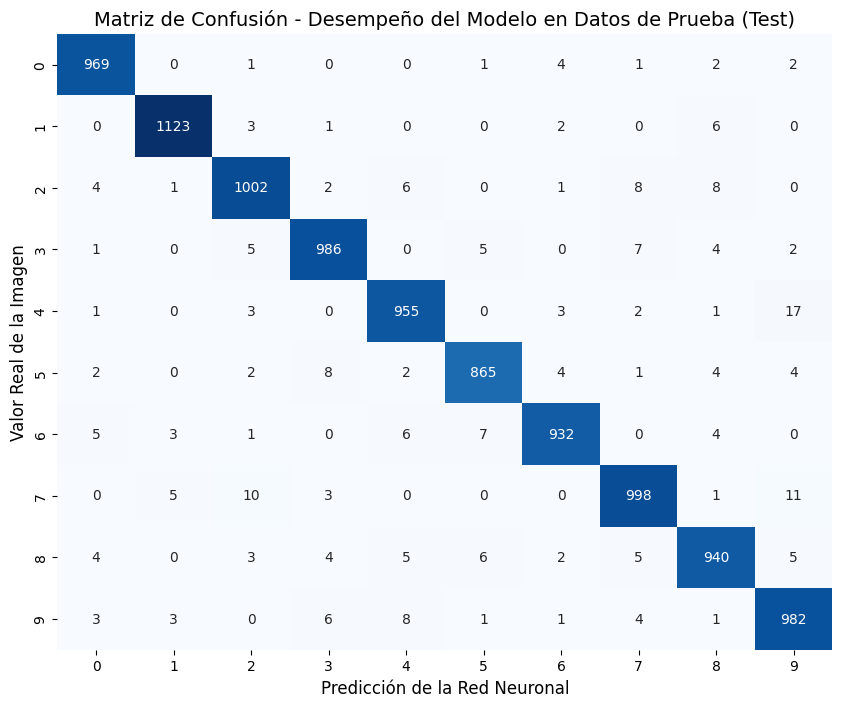

In [30]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import torch

# 1. Extracción de datos: 
modelo_2.eval() 
todas_predicciones = []
todas_etiquetas = []

with torch.no_grad(): 
    for inputs, labels in loader_test:
        logits = modelo_2(inputs)
        
        # Extraemos el índice de la clase con mayor probabilidad
        _, predicciones = torch.max(logits, 1)
        
       
        todas_predicciones.extend(predicciones.numpy())
        todas_etiquetas.extend(labels.numpy())

# 2. Transformación: Calculamos la Matriz de Confusión matemática
matriz = confusion_matrix(todas_etiquetas, todas_predicciones)

# 3. Renderizado: Mapa de calor de las inferencias
plt.figure(figsize=(10, 8))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', cbar=False)

# Configuración de las etiquetas arquitectónicas
plt.title('Matriz de Confusión - Desempeño del Modelo en Datos de Prueba (Test)', fontsize=14)
plt.xlabel('Predicción de la Red Neuronal', fontsize=12)
plt.ylabel('Valor Real de la Imagen', fontsize=12)

plt.show()

# 6.2 Analisis de la Matriz

## Naturaleza del Dataset
- Las imagenes no tienen ruido de fondo, centradas y normalizadas
- Al aplanarlo a un vector de 784 dimensiones casi siempre encienden exactamente las mismas neuronas de entrada en la capa nn.Linear

## La revelacion de la arquitectura de la red
- El modelo no es perfecto 
- Edge cases como el escribir rapido un 4, los pixeles pueden parecer un 9. Muchas personas escriben el 7 con una linea en el medio, puede activar neuronas de la base horizontal del 2.

# 7 Visualizador de Predicciones

- Tomamos una pequeña muestra del conjunto de prueba
- Aplicaremos transformacion **softmax** y comprimirlos en un rango de 0.0-1.0
- **Usando la operacion torch.max** para obtener el indice del valor y el valor en si.
- Usando **matplolib** se genera la matriz de pixeles y se colocan los datos 

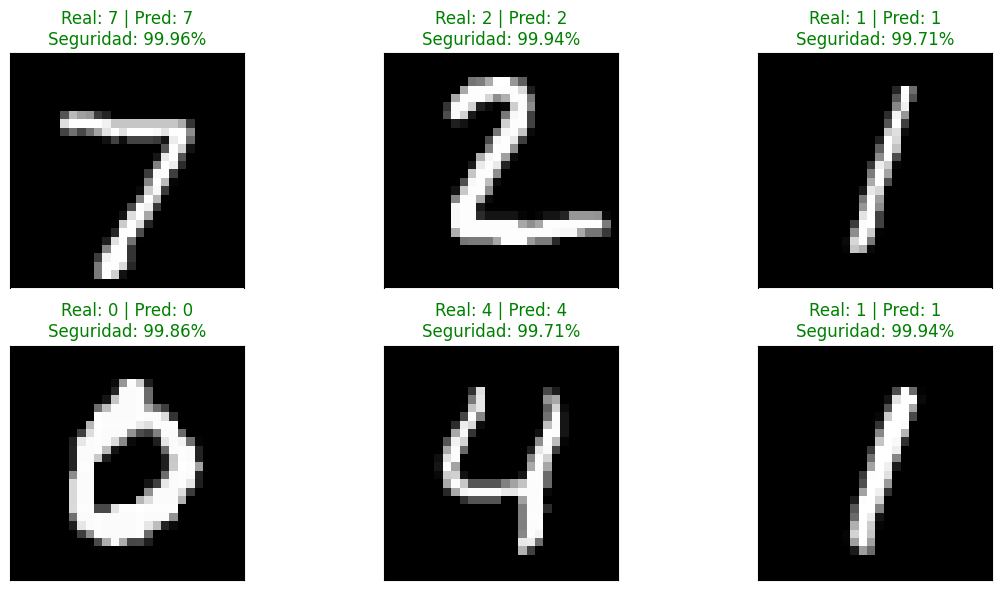

In [31]:
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torch


dataiter = iter(loader_test)
imagenes, etiquetas_reales = next(dataiter)

# 2. Lógica de Inferencia
modelo_2.eval() 
with torch.no_grad():
    # Paso hacia adelante: obtenemos los logits de la última capa
    logits = modelo_2(imagenes)
    
    
    probabilidades = F.softmax(logits, dim=1)
    
    # Extraemos el valor máximo (confianza) y la posición de ese valor (predicción)
    nivel_confianza, predicciones = torch.max(probabilidades, dim=1)

# 3. Visualización (Mostraremos las primeras 6 imágenes del batch)
fig = plt.figure(figsize=(12, 6))

for i in range(6):
    # Crear subgráficos en una cuadrícula de 2 filas por 3 columnas
    ax = fig.add_subplot(2, 3, i+1, xticks=[], yticks=[])
    
   
    img_render = imagenes[i].squeeze().numpy()
    ax.imshow(img_render, cmap='gray')
    
    # Extraer los datos individuales de los tensores
    pred_val = predicciones[i].item()
    real_val = etiquetas_reales[i].item()
    seguridad_pct = nivel_confianza[i].item() * 100 
    

    color_texto = 'green' if pred_val == real_val else 'red'
    
    ax.set_title(f'Real: {real_val} | Pred: {pred_val}\nSeguridad: {seguridad_pct:.2f}%', color=color_texto)

plt.tight_layout()
plt.show()

# 8. Reflexion Personal